In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np

cdf=pd.read_csv('cleaned_datasett/customer.csv')
pdf=pd.read_json('cleaned_datasett/product.json')
odf=pd.read_excel('cleaned_datasett/orders.xlsx')


## plot the no_of_customers based on age category


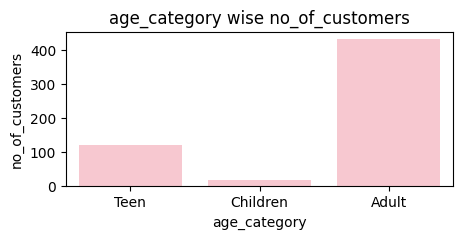

In [28]:
plt.figure(figsize=(5,2))
sns.countplot(cdf, x= 'age_category',color = 'pink')
plt.title('age_category wise no_of_customers')
plt.ylabel('no_of_customers')
plt.show()

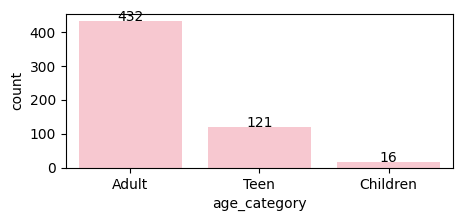

In [29]:
plt.figure(figsize = (5,2))
c = sns.countplot(cdf,x = 'age_category',order = ['Adult', 'Teen', 'Children'],color = 'pink')
c.bar_label(c.containers[0],padding = -2) #Data Labels 
plt.show()


**observation**
the no.of adult is more than teens and children combined


## 2. plot the portion/ percentage of marital_status


In [30]:
m = cdf['married'].value_counts()

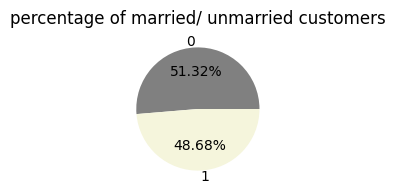

In [31]:
plt.figure(figsize=(2,2))
plt.pie(x=m.values, labels=m.index, autopct='%.2f%%', colors=['gray', 'beige'])
plt.title('percentage of married/ unmarried customers')
plt.show()

## 3. plot the distribution of customers age


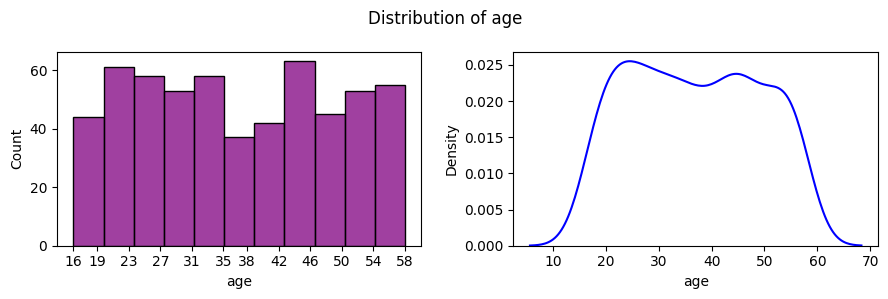

In [33]:
# plt.figure(figsize=(7,3))
fig, axes = plt.subplots(1,2, figsize=(9,3))  # return tow fig, axes
sns.histplot(cdf, x='age', ax=axes[0], color='purple')
sns.kdeplot(cdf, x='age', ax=axes[1], color='blue')


plt.suptitle('Distribution of age')
plt.tight_layout()

axes[0].set_xticks(np.linspace(16,58,12,dtype=int))
plt.show()

**observation**
42-46 aged customers are high in number followed by 19-23(age)


## 4. analyse the trend of new_registration


extract year from date column


In [34]:
cdf['registered_date']=pd.to_datetime(cdf['registered_date'])
temps = (cdf['registered_date'].dt.year).value_counts().sort_index()
temps

registered_date
2017    10
2018    74
2019    75
2020    71
2021    75
2022    63
2023    75
2024    75
2025    51
Name: count, dtype: int64

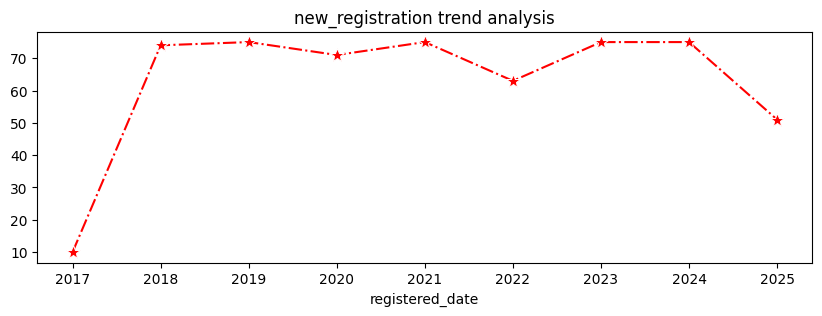

In [35]:
plt.figure(figsize=(10, 3))
sns.lineplot(x=temps.index, y=temps.values, linestyle='-.', marker='*', markersize=10, color='red')
plt.title('new_registration trend analysis')
plt.show()
# sns.lineplot(x=temps.index, y=temps.values)

<Axes: xlabel='registered_date', ylabel='count'>

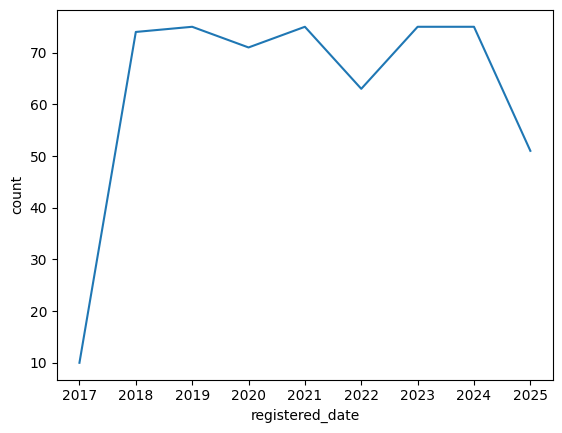

In [36]:
tempd = (cdf['registered_date'].dt.year).value_counts().sort_index().reset_index()
tempd
sns.lineplot(data=tempd, x='registered_date', y='count')

doing on product tables


In [37]:
pdf.columns

Index(['product_id', 'price', 'discount', 'expiry_date', 'stock', 'ratings',
       'discounted amount', 'amazon', 'flipkart', 'product', 'category'],
      dtype='object')

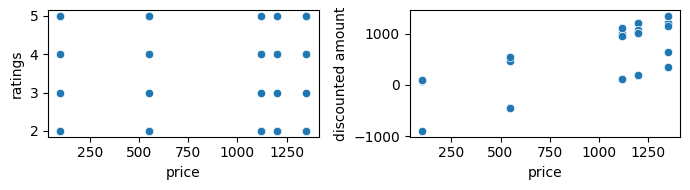

In [38]:
fig, axes = plt.subplots(1,2, figsize=(7,2))
sns.scatterplot(pdf, x = 'price', y='ratings', ax=axes[0])
sns.scatterplot(pdf, x = 'price', y='discounted amount', ax=axes[1])

plt.tight_layout()
plt.show()

__# 6. (i) plot the corelation b/w price and ratings__

__# (ii) plot the corelationship b/t price and discount_amount__


In [40]:
c = pdf.corr(numeric_only=True)
c

,price,expiry_date,ratings,discounted amount,amazon,flipkart
price,1.000000,0.032652,-0.020165,0.681645,0.095372,-0.200884
expiry_date,0.032652,1.000000,-0.044236,-0.033853,0.003472,0.043519
ratings,-0.020165,-0.044236,1.000000,-0.005787,0.081444,0.110868
discounted amount,0.681645,-0.033853,-0.005787,1.000000,0.133781,0.198350
amazon,0.095372,0.003472,0.081444,0.133781,1.000000,0.147753
flipkart,-0.200884,0.043519,0.110868,0.198350,0.147753,1.000000


<Axes: >

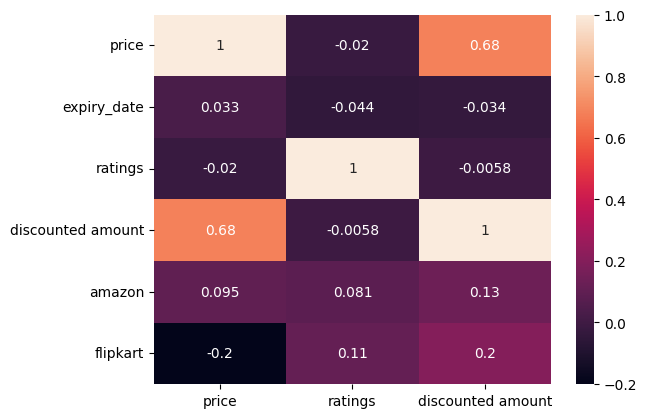

In [41]:
cr = c[['price', 'ratings', 'discounted amount']]
sns.heatmap(cr, annot=True)

<Axes: >

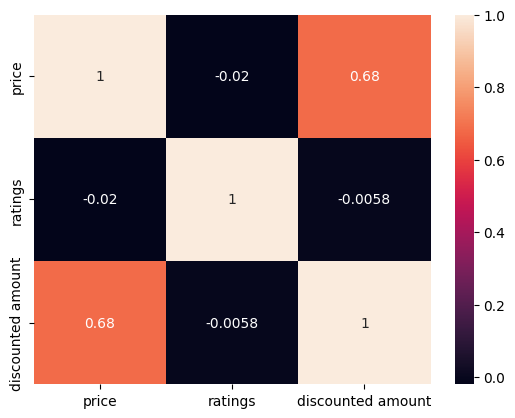

In [42]:
cr = c.loc[['price', 'ratings', 'discounted amount'],['price', 'ratings', 'discounted amount']]
sns.heatmap(cr, annot=True)

df.loc[row_selection, column_selection]

df.loc[row_conds, column_names]

df.loc[row_indies, column_names]


## 7. Plot the total revenue for each product_category

In [43]:
temp = pd.merge(pdf[['product_id','category']],
        odf[['product_id','amount_to_be_paid']],
        how = 'inner', on = 'product_id')

In [44]:
temp

,product_id,category,amount_to_be_paid
0,P1003,Accessories,1400
1,P1003,Accessories,1050
2,P1003,Accessories,350
3,P1003,Accessories,1750
4,P1003,Accessories,1400
...,...,...,...
486,P1098,Hygiene,4080
487,P1098,Hygiene,5100
488,P1098,Hygiene,1020
489,P1098,Hygiene,1020


In [ ]:
idx = temp.groupby(by = 'category').agg({'amount_to_be_paid':'sum'}).sort_values('amount_to_be_paid', ascending = True).index

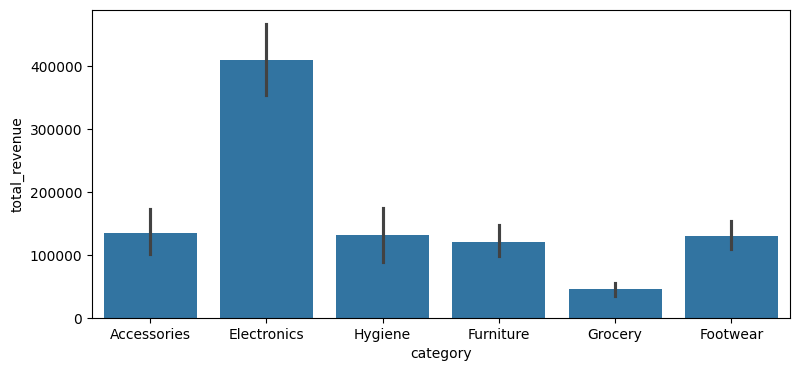

In [45]:
plt.figure(figsize=(9,4))
sns.barplot(data = temp, x = 'category', y = 'amount_to_be_paid',estimator = 'sum')
#It Groups the caategory_column and applies simulation and y axis (amount_to_be_paid)
plt.ylabel('total_revenue')
plt.show()

Find premium and non premium wrt genders


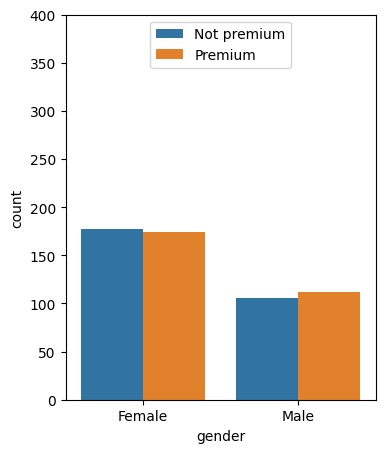

In [2]:
plt.figure(figsize=(4,5))
sns.countplot(cdf,x='gender',hue='premium_status')
plt.yticks((0,50,100,150,200,250,300,350,400))
plt.legend(labels=['Not premium','Premium'],loc='upper center')
plt.show()

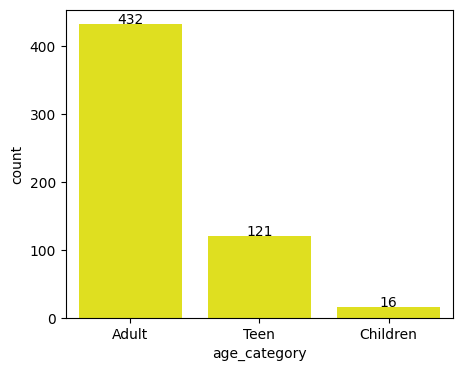

In [3]:
plt.figure(figsize=(5,4))
c=sns.countplot(cdf,x='age_category',order=['Adult','Teen','Children'],color='yellow')
c.bar_label(c.containers[0],padding=-2)
plt.show()

C:\Users\sambit kumar singh\AppData\Local\Temp\ipykernel_28360\2466415262.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:pink'` for the same effect.

  c=sns.countplot(cdf,x='gender',hue='premium_status',color='pink')


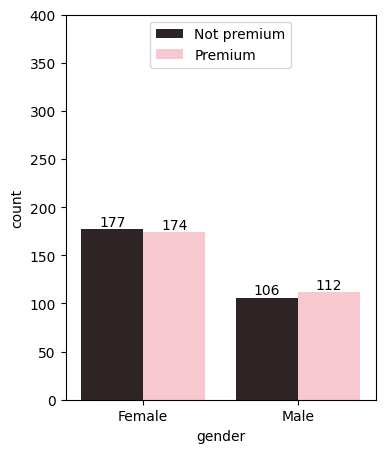

In [ ]:
plt.figure(figsize=(4,5))
c=sns.countplot(cdf,x='gender',hue='premium_status',color='pink')
for i in c.containers:
 c.bar_label(i)
plt.yticks((0,50,100,150,200,250,300,350,400))
plt.legend(labels=['Not premium','Premium'],loc='upper center')
plt.show()

In [17]:
temp=pd.merge(pdf[['product_id','category']],odf[['customer_id','product_id','amount_to_be_paid']],how='inner',on='product_id')
temp=pd.merge(temp,cdf[['customer_id','gender']])
idx=temp.groupby(by='category').agg({'amount_to_be_paid':'sum'}).sort_values('amount_to_be_paid',ascending=True).index

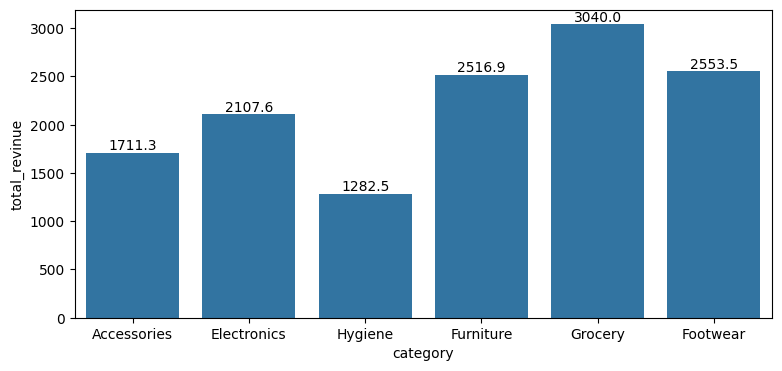

In [18]:
plt.figure(figsize=(9,4))
b=sns.barplot(data=temp,x='category',y='amount_to_be_paid',errorbar=None,)
b.bar_label(b.containers[0],fmt='%.1f')
plt.ylabel('total_revinue')
plt.show()

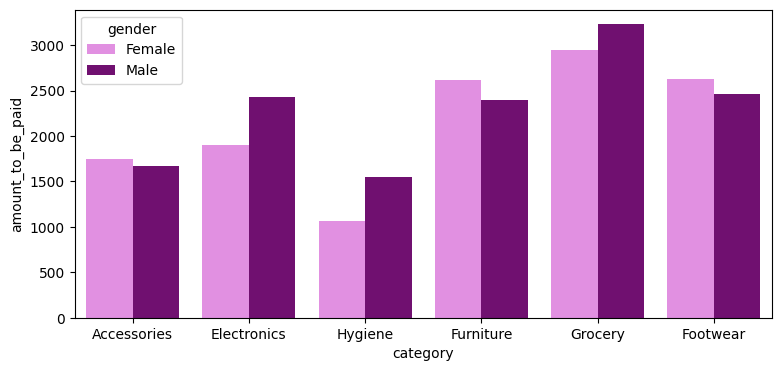

In [21]:
plt.figure(figsize=(9,4))
sns.barplot(data=temp,x='category',y='amount_to_be_paid',estimator='mean',errorbar=None,hue='gender',palette=['violet','purple'])
plt.show()

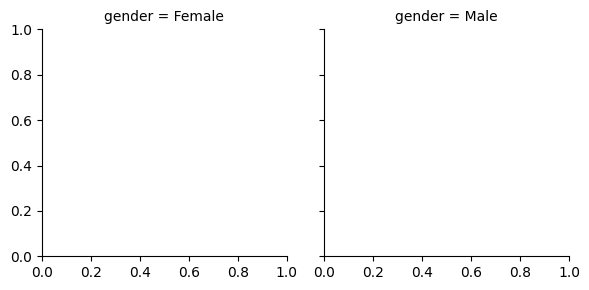

In [22]:
sns.FacetGrid(temp,col='gender')

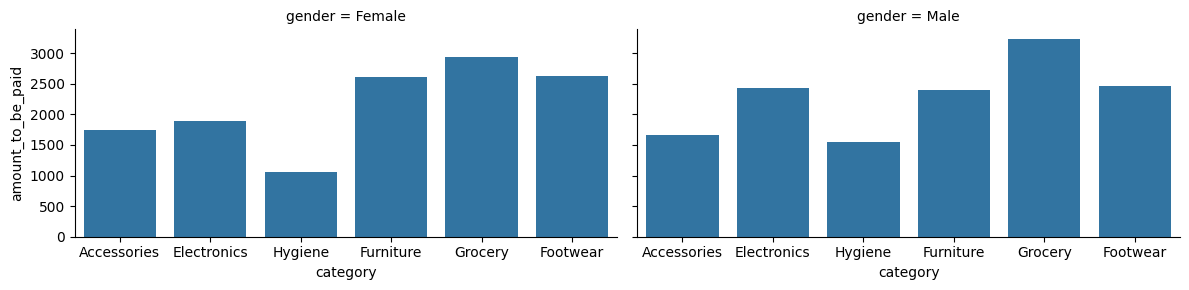

In [26]:
fg=sns.FacetGrid(temp,col='gender',height=3,aspect=2)
fg.map_dataframe(sns.barplot,x='category',y='amount_to_be_paid',estimator='mean',errorbar=None)
plt.show()